In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [102]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [103]:
from sklearn.model_selection import train_test_split

In [104]:
from sklearn.ensemble import RandomForestClassifier

In [105]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [106]:
from sklearn.cluster import KMeans

In [107]:
df = pd.read_excel("/content/Telco_customer_churn.xlsx")

In [108]:
print("Shape:", df.shape)

Shape: (7043, 33)


In [109]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [110]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [111]:
print("\nMissing Values")
print(df.isnull().sum())


Missing Values
CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64


In [112]:
print("\nChurn Distribution")
print(df['Churn Label'].value_counts())


Churn Distribution
Churn Label
No     5174
Yes    1869
Name: count, dtype: int64


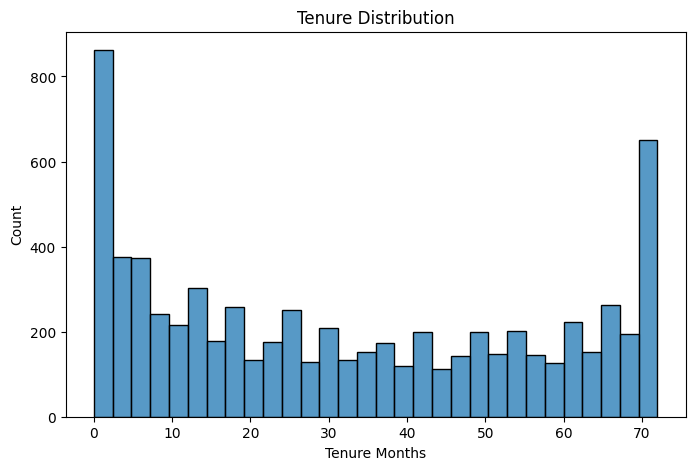

In [113]:
plt.figure(figsize=(8,5))
sns.histplot(df['Tenure Months'], bins=30)
plt.title("Tenure Distribution")
plt.show()

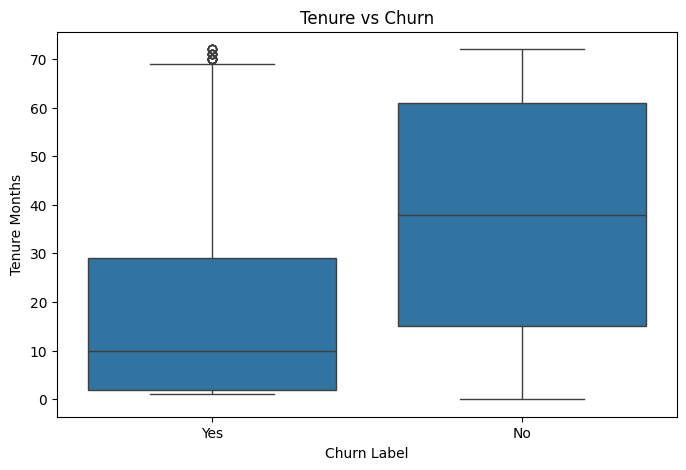

In [114]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='Churn Label',
    y='Tenure Months',
    data=df
)
plt.title("Tenure vs Churn")
plt.show()

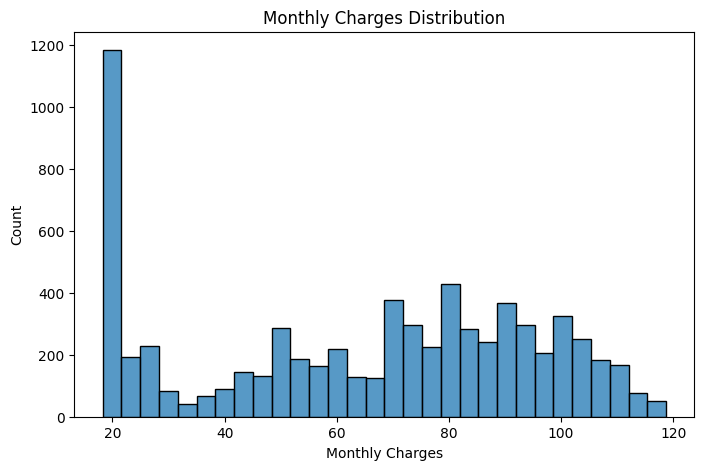

In [115]:
plt.figure(figsize=(8,5))
sns.histplot(df['Monthly Charges'], bins=30)
plt.title("Monthly Charges Distribution")
plt.show()

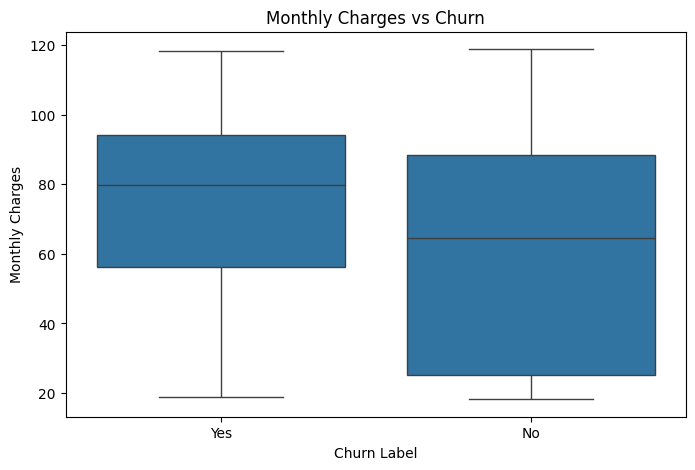

In [116]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='Churn Label',
    y='Monthly Charges',
    data=df
)
plt.title("Monthly Charges vs Churn")
plt.show()

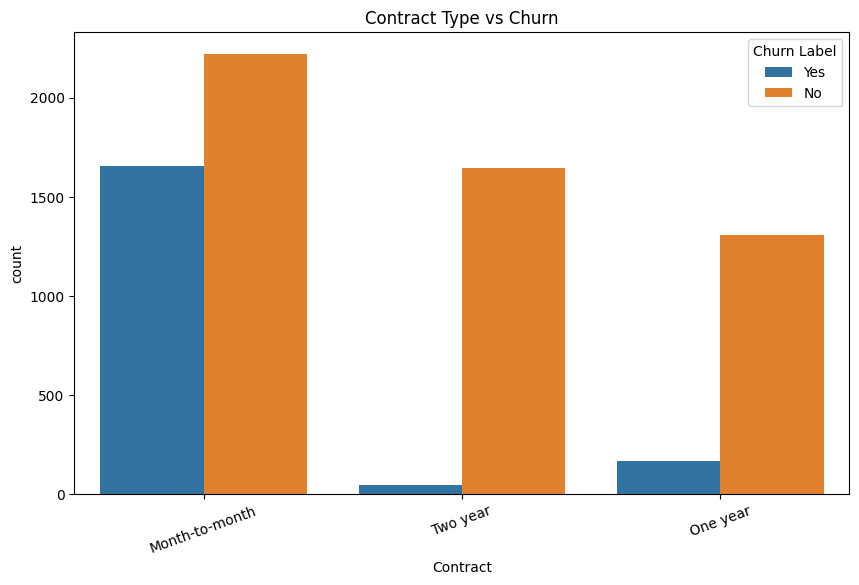

In [117]:
plt.figure(figsize=(10,6))
sns.countplot(
    x='Contract',
    hue='Churn Label',
    data=df
)
plt.title("Contract Type vs Churn")
plt.xticks(rotation=20)
plt.show()


In [118]:
df_ml = df.copy()

In [119]:
le = LabelEncoder()

In [120]:
df_ml['Total Charges'] = pd.to_numeric(df_ml['Total Charges'], errors='coerce')
df_ml['Total Charges'] = df_ml['Total Charges'].fillna(0)

for col in df_ml.columns:
    if df_ml[col].dtype == 'object':
        if df_ml[col].isnull().any():
            df_ml[col] = df_ml[col].fillna('Unknown_Category')
        df_ml[col] = le.fit_transform(df_ml[col])

In [121]:
X = df_ml.drop('Churn Label', axis=1)
y = df_ml['Churn Label']

In [122]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [123]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [124]:
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [125]:
y_pred = rf.predict(X_test)

In [126]:
accuracy = accuracy_score(y_test, y_pred)

In [127]:
print("\nAccuracy:", accuracy)


Accuracy: 1.0


In [128]:
print("\nClassification Report")
print(classification_report(y_test, y_pred))


Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1009
           1       1.00      1.00      1.00       400

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409



In [129]:
cm = confusion_matrix(y_test, y_pred)

In [130]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

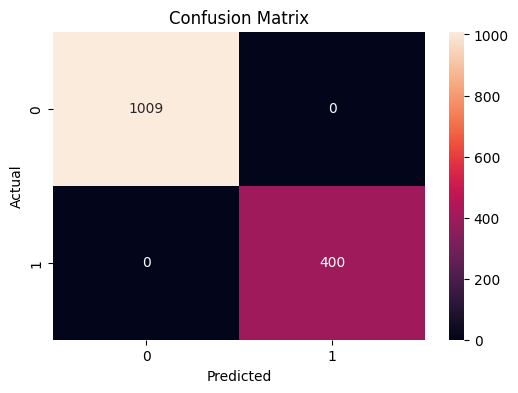

In [131]:
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [132]:
importance = importance.sort_values(
    by='Importance',
    ascending=False
)

In [133]:
print("\nTop Features")
print(importance.head(10))


Top Features
            Feature  Importance
28      Churn Value    0.460517
31     Churn Reason    0.288548
29      Churn Score    0.147521
23         Contract    0.025784
17  Online Security    0.015629
13    Tenure Months    0.011420
20     Tech Support    0.009975
27    Total Charges    0.006045
26  Monthly Charges    0.005174
12       Dependents    0.005113


In [134]:
segment_features = df[
    ['Tenure Months', 'Monthly Charges']
]

In [135]:
scaler = StandardScaler()

In [136]:
scaled_data = scaler.fit_transform(
    segment_features
)

In [137]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

In [138]:
df['Segment'] = kmeans.fit_predict(
    scaled_data
)

In [139]:
print("\nSegment Count")
print(df['Segment'].value_counts())


Segment Count
Segment
1    2205
3    1951
2    1732
0    1155
Name: count, dtype: int64


In [140]:
plt.figure(figsize=(8,6))

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

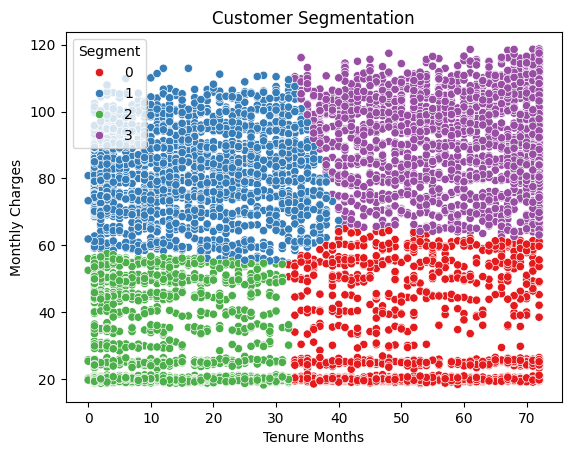

In [141]:
sns.scatterplot(
    data=df,
    x='Tenure Months',
    y='Monthly Charges',
    hue='Segment',
    palette='Set1'
)
plt.title("Customer Segmentation")
plt.show()

In [99]:
df.to_excel(
    "Customer_Churn_Segmentation_Output.xlsx",
    index=False
)

In [100]:
print("\nProject Completed Successfully")


Project Completed Successfully
